In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Read the dataset in panda's dataframe

df = pd.read_csv('churn raw data.csv')

# Exploratory Data Analysis

In [3]:
# let's see the dataset carefully
print(df.shape)
df.head()


(10001, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0


In [4]:
# identify any missing entries in the dataset
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
#Basic statistical analysis
df.describe() 

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10001.000000,1.000100e+04,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000
mean,5000.000100,1.569093e+07,650.525647,38.922108,5.012499,76478.241464,1.530147,0.705529,0.515148,100090.365732,0.203780
std,2887.184182,7.193480e+04,96.648980,10.487327,2.892187,62398.972612,0.581649,0.455827,0.499795,57507.618598,0.402827
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2500.000000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,51011.290000,0.000000
50%,5000.000000,1.569073e+07,652.000000,37.000000,5.000000,97188.620000,1.000000,1.000000,1.000000,100200.400000,0.000000
75%,7500.000000,1.575323e+07,718.000000,44.000000,7.000000,127642.440000,2.000000,1.000000,1.000000,149384.430000,0.000000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [6]:
df['Exited'].value_counts() # contains counts of unique values in Exited column
# df.Exited.value_counts()

0    7963
1    2038
Name: Exited, dtype: int64

In [7]:
# print out the columns
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
#Separate the Independent variables (X) from dependent variable (y)
colsToDrop = ['RowNumber', 'CustomerId', 'Surname']
df.drop(columns = colsToDrop, inplace = True)
# df = df.drop(columns = colsToDrop)
y = df['Exited']
X = df.drop(columns = 'Exited')
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,619,France,Female,42,2,0.00,1,1,1,101348.88
2,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
3,502,France,Female,42,8,159660.80,3,1,0,113931.57
4,699,France,Female,39,1,0.00,2,0,0,93826.63


In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,699,France,Female,39,1,0.00,2,0,0,93826.63,0


# Train Test Split

In [10]:
# Return an one-dimensional array containing counts of unique values
df['Exited'].value_counts()

0    7963
1    2038
Name: Exited, dtype: int64

In [11]:
# imbalanced balance
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20)

In [12]:
y_test.value_counts() # without stratify 2038 * 0.2 = 407.6

0    1617
1     384
Name: Exited, dtype: int64

In [13]:
# imbalanced balance
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20, stratify = y)
# data is split in a stratified fashion, using the class labels

In [14]:
y_test.value_counts()

0    1593
1     408
Name: Exited, dtype: int64

# ZeroR classifier

In [15]:
# Confusion Matrix function; w

def plot_confusion_matrix(cm, classes=None, title='Confusion matrix'):
    """Plots a confusion matrix."""
    if classes is not None:
        sns.heatmap(cm, xticklabels=classes, yticklabels=classes, vmin=0., vmax=1., annot=True, annot_kws={'size':50})
    else:
        sns.heatmap(cm, vmin=0., vmax=1.)
    plt.title(title)
    plt.ylabel('True label', fontsize = 20)
    plt.xlabel('Predicted label', fontsize = 20)

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
dummy_clf = DummyClassifier(strategy = 'most_frequent', random_state = 20) # ZeroR classifier object/instance
dummy_clf.fit(X_train, y_train) # ML model training on training set
y_pred = dummy_clf.predict(X_test) # ML model tested on test set only X_test, No y_test
print(classification_report(y_test, y_pred))
print("Train Accuracy: ", accuracy_score(y_train, dummy_clf.predict(X_train))) # compare training actual and predicted value
print("Test Accuracy: ", accuracy_score(y_test, y_pred)) # compare test actual and predicted value

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       408

    accuracy                           0.80      2001
   macro avg       0.40      0.50      0.44      2001
weighted avg       0.63      0.80      0.71      2001

Train Accuracy:  0.79625
Test Accuracy:  0.7961019490254873


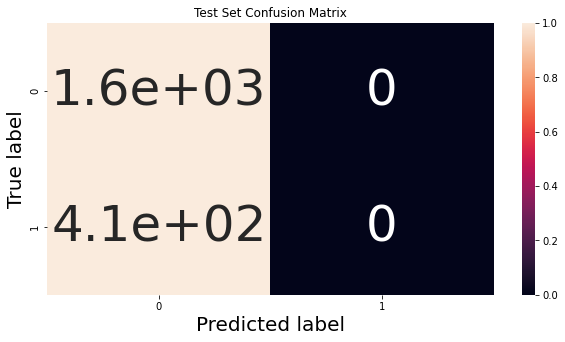

In [17]:
y_pred = dummy_clf.predict(X_test)

# Plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm/cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize = (10,5))
plot_confusion_matrix(cm, classes=dummy_clf.classes_, title='Test Set Confusion Matrix')

In [18]:
#Accuracy from the confusion matrix
(1.6e+3)/(1.6e+3 + 4.1e+2)

0.7960199004975125

# K-Nearest Neighbor

In [19]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,699,France,Female,39,1,0.00,2,0,0,93826.63,0


# Data Pre-Processing

In [20]:
#We need to provide numerical representations to categotical attributes 
# Convert categorical variable into dummy/indicator variables
df = pd.get_dummies(df, columns = ['Geography'])

In [21]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,619,Female,42,2,0.00,1,1,1,101348.88,1,1,0,0
2,608,Female,41,1,83807.86,1,0,1,112542.58,0,0,0,1
3,502,Female,42,8,159660.80,3,1,0,113931.57,1,1,0,0
4,699,Female,39,1,0.00,2,0,0,93826.63,0,1,0,0


# Dummy variable trap: 
When you can derive one variable from other variables, they are known to be multi-colinear. Here if you know values of Germany and Spain then you can easily infer value of France, i.e. Germany=0 and Spain=0. These variables are called to be multi-colinear. In this situation some ML models won't work as expected. Hence you need to drop one column.

NOTE: sklearn library takes care of dummy variable trap hence even if you don't drop one of the dummy variable columns it is going to work, however we should make a habit of taking care of dummy variable trap ourselves just in case library that you are using is not handling this for you

In [22]:
 df = df.drop(['Geography_France'], axis='columns')
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,0,0
1,619,Female,42,2,0.00,1,1,1,101348.88,1,0,0
2,608,Female,41,1,83807.86,1,0,1,112542.58,0,0,1
3,502,Female,42,8,159660.80,3,1,0,113931.57,1,0,0
4,699,Female,39,1,0.00,2,0,0,93826.63,0,0,0


In [23]:
# We will use the label encoder to encode gender
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() # instantiate label encoder in an object le
df['Gender'] =le.fit_transform(df['Gender']) 

In [24]:
print(df.shape)
df.head(10)

(10001, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
2,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
3,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
4,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
5,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1
6,645,1,44,8,113755.78,2,1,0,149756.71,1,0,1
7,822,1,50,7,0.00,2,1,1,10062.80,0,0,0
8,376,0,29,4,115046.74,4,1,0,119346.88,1,1,0
9,501,1,44,4,142051.07,2,0,1,74940.50,0,0,0


In [25]:
#Let's now split the dataset in the same way we have done for ZeroR classifier
y = df['Exited']
X = df.drop(columns = 'Exited')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20, stratify = y)

In [26]:
# We need to scale correctly (We will use MinMax Scaler to do this)
from sklearn.preprocessing import MinMaxScaler
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'] # new list of columns for scaling
scaler = MinMaxScaler() # instantiate min_max_scaler in an object scaler
# learn/fit min_max_scaler from train set
# After learning/fit, apply min_max_scaler in both train and test set to transform
scaler.fit(X_train[cols_to_scale]) # learning min and max parameters from X_train
# scaler.fit(X[cols_to_scale]) is NOT correct
X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [27]:
X_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
285,0.898,0,0.054054,0.8,0.694250,0.333333,0,1,0.963203,0,0
7139,0.160,0,0.648649,0.6,0.539631,0.333333,1,1,0.864285,1,0
2064,0.476,0,0.229730,0.1,0.410767,0.000000,1,0,0.899358,1,0
8701,0.718,1,0.067568,0.8,0.292206,0.333333,1,0,0.317205,1,0
9892,0.660,1,0.418919,1.0,0.000000,0.333333,1,0,0.935074,0,0


In [28]:
X_test.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
4406,0.428,0,0.229730,0.9,0.000000,0.333333,1,1,0.529180,0,1
205,0.324,1,0.202703,0.3,0.704137,0.000000,1,0,0.473341,0,1
6589,0.378,1,0.135135,0.5,0.000000,0.333333,1,0,0.241877,0,1
5117,0.782,1,0.270270,0.4,0.510230,0.000000,1,0,0.292172,1,0
295,0.662,1,0.270270,0.3,0.000000,0.333333,1,1,0.562456,0,0


# KNN

In [29]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2) # Euclidean Distance Metric
knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Train Accuracy: ", accuracy_score(y_train, knn_clf.predict(X_train)))
print("Test Accuracy: ", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.95      0.90      1593
           1       0.63      0.31      0.41       408

    accuracy                           0.82      2001
   macro avg       0.74      0.63      0.65      2001
weighted avg       0.80      0.82      0.80      2001

Train Accuracy:  0.864375
Test Accuracy:  0.8225887056471765


In [30]:
# hyperparameter tuning
k = range(1, 60)
train_acc = [] # create empty list
test_acc = []
for x in k:
    knn_clf = KNeighborsClassifier(n_neighbors = x, metric = 'minkowski', p = 2) # Euclidean Distance Metric
    knn_clf.fit(X_train, y_train)
    y_pred = knn_clf.predict(X_test)
    train_acc.append(accuracy_score(y_train, knn_clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, y_pred))
    
    

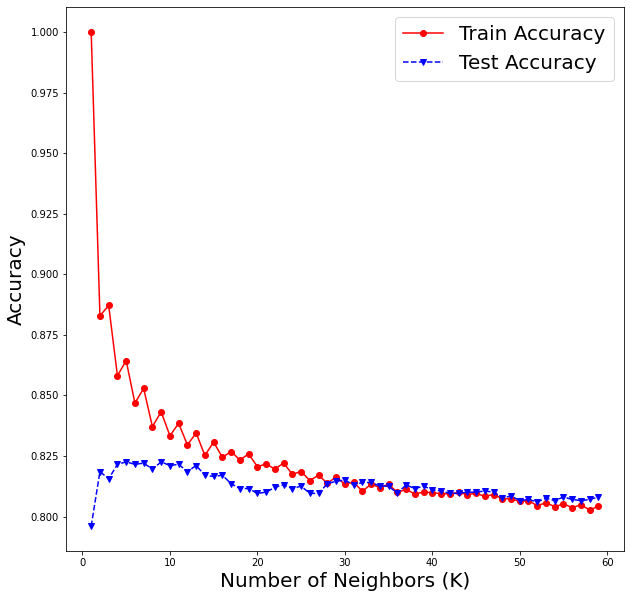

In [31]:
plt.figure(figsize = (10,10))
plt.plot(k,train_acc,'ro-',k,test_acc,'bv--')
plt.legend(['Train Accuracy','Test Accuracy'], fontsize = 20)
plt.xlabel('Number of Neighbors (K)', fontsize = 20)
plt.ylabel('Accuracy', fontsize = 20);

In [32]:
for x in k:
    print('Number of neighbors = ', x, "Train accuracy = ", train_acc[x-1], "Test Accuracy = ", test_acc[x-1], "Difference = ",
         (abs(train_acc[x-1] - test_acc[x-1])*100), "%")

Number of neighbors =  1 Train accuracy =  1.0 Test Accuracy =  0.7961019490254873 Difference =  20.389805097451273 %
Number of neighbors =  2 Train accuracy =  0.882875 Test Accuracy =  0.8185907046476761 Difference =  6.428429535232382 %
Number of neighbors =  3 Train accuracy =  0.887125 Test Accuracy =  0.815592203898051 Difference =  7.153279610194907 %
Number of neighbors =  4 Train accuracy =  0.858125 Test Accuracy =  0.8215892053973014 Difference =  3.6535794602698624 %
Number of neighbors =  5 Train accuracy =  0.864375 Test Accuracy =  0.8225887056471765 Difference =  4.178629435282355 %
Number of neighbors =  6 Train accuracy =  0.846875 Test Accuracy =  0.8215892053973014 Difference =  2.528579460269864 %
Number of neighbors =  7 Train accuracy =  0.852875 Test Accuracy =  0.8220889555222389 Difference =  3.078604447776112 %
Number of neighbors =  8 Train accuracy =  0.837125 Test Accuracy =  0.8195902048975512 Difference =  1.753479510244882 %
Number of neighbors =  9 Tra